<a href="https://colab.research.google.com/github/saladnga/CS4410-Homeworks/blob/main/ExtraCredits_CS4410_AnVuHoang_1677986.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objective:
Use a pretrained deep learning model (ResNet or MobileNet) to classify images using PyTorch in Google Colab. You'll apply transfer learning to run inference on real-world images and interpret the top predictions.



Import libraries

In [15]:
import torch
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

Enable GPU (if available)

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

Using device: cuda



Load Pretrained ResNet50 model with the new torchvision weights API

In [17]:
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

Set model to evaluation mode

In [18]:
model.eval()
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Get ImageNet class labels and preprocessing transform with weights API integrated

In [19]:
categories = weights.meta["categories"]
preprocess = weights.transforms()

Function to load image, predict and display results

In [20]:
def classify_image(url):
  # Header to avoid invalid requests
  response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
  # Try catch to prevent errors
  try:

    # Preprocess the image
    img = Image.open(BytesIO(response.content)).convert('RGB')
    batch = preprocess(img).unsqueeze(0).to(device)

    # Run Inference
    with torch.no_grad():
      prediction = model(batch).squeeze(0)

    # Convert to probabilities using softmax
    probabilities = torch.nn.functional.softmax(prediction, dim=0)

    # Extract top 5 probabilities with indexes
    top_5_probabilities, top_5_indices = torch.topk(probabilities, 5)

    # Display the image
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Display top 5 predictions
    print("Top 5 predictions:")
    for i in range(top_5_probabilities.size(0)):
      score = top_5_probabilities[i].item() * 100
      category_name = categories[top_5_indices[i].item()]
      print(f"{category_name}: {score:.2f}%")

  # Display error
  except Exception as e:
    print(f"Error processing image from URL: {url}")
    print(f"Error: {type(e).__name__}: {e}")

Classify 3 different real-world images (E.g: Pug, Golden Retriever, Space Shuttle)

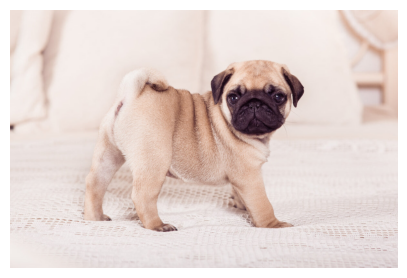

Top 5 predictions:
pug: 35.09%
Brabancon griffon: 1.22%
bull mastiff: 0.65%
tub: 0.50%
chow: 0.43%


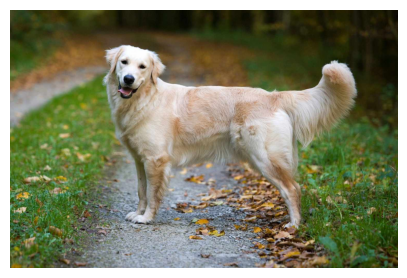

Top 5 predictions:
golden retriever: 23.75%
kuvasz: 1.92%
flat-coated retriever: 1.31%
Labrador retriever: 0.63%
Gordon setter: 0.53%


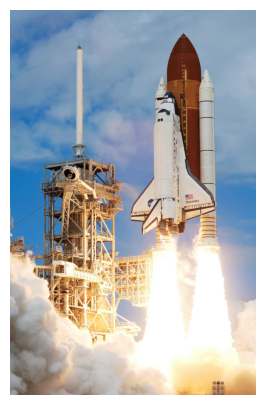

Top 5 predictions:
space shuttle: 54.14%
missile: 0.29%
projectile: 0.23%
matchstick: 0.13%
drilling platform: 0.11%


In [21]:
image_urls = [
    "https://nativepet.com/cdn/shop/articles/Pug-puppy-standing-on-a-bed.jpg?v=1667820606",
    "https://www.dailypaws.com/thmb/DQfQglzyKWlVSlsDwKPprF2iMSg=/1500x0/filters:no_upscale():max_bytes(150000):strip_icc()/golden-retriever-177213599-2000-a30830f4d2b24635a5d01b3c5c64b9ef.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/d/d6/STS120LaunchHiRes-edit1.jpg",
]

# Loop through the image URLs
for url in image_urls:
    classify_image(url)